# Dynamic Price Prediction Model

In [2]:
import pandas as pd

# Load all CSVs
dim_date = pd.read_csv("dim_date.csv")
dim_hotels = pd.read_csv("dim_hotel.csv")
dim_rooms = pd.read_csv("dim_rooms.csv")
fact_aggregated_bookings = pd.read_csv("fact_aggregated_bookings.csv")
fact_bookings = pd.read_csv("fact_bookings.csv")


## Merging Hotel with Fact_Booking

In [2]:
# Merge hotels with fact_bookings
fact_bookings = fact_bookings.merge(dim_hotels, on="property_id", how="left")
fact_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,LOS,ADR,booking_diff,property_name,category,city
0,Jul012216558RT28,16558,29-06-2022,01-07-2022,03-07-2022,2,RT2,direct offline,NaN,Cancelled,12600,5040,2,2520.000000,2,Atliq Grands,Luxury,Delhi
1,Jul012216559RT115,16559,10-06-2022,01-07-2022,02-07-2022,2,RT1,direct offline,NaN,Cancelled,11050,4420,1,4420.000000,21,Atliq Exotica,Luxury,Mumbai
2,Jul012216559RT116,16559,29-06-2022,01-07-2022,06-07-2022,3,RT1,direct offline,NaN,Cancelled,12155,4862,5,972.400000,2,Atliq Exotica,Luxury,Mumbai
3,Jul012216559RT119,16559,29-06-2022,01-07-2022,07-07-2022,2,RT1,direct offline,4.0,Checked Out,11050,11050,6,1841.666667,2,Atliq Exotica,Luxury,Mumbai
4,Jul022216559RT11,16559,29-06-2022,02-07-2022,03-07-2022,1,RT1,direct offline,4.0,Checked Out,11050,11050,1,11050.000000,3,Atliq Exotica,Luxury,Mumbai


## Check for Dupliactes

In [3]:
# Check how many duplicate booking_ids exist
fact_bookings.duplicated(subset='booking_id').sum()


np.int64(0)

In [4]:
# drop not used columns
fact_bookings.drop(["booking_id", "LOS","booking_date", "checkout_date", "revenue_generated", 
                    "revenue_realized","booking_status","no_guests"], 
                   axis=1, inplace=True)
# fact_bookings

## fact_aggregated_bookings table
### Calculating Occupancy & merging with fact_bookings

In [5]:
# change date format
fact_aggregated_bookings["check_in_date"] = pd.to_datetime(fact_aggregated_bookings["check_in_date"])
fact_aggregated_bookings["check_in_date"] = fact_aggregated_bookings["check_in_date"].dt.strftime('%d-%m-%Y')
fact_aggregated_bookings.head()

C:\Users\Darshan\AppData\Local\Temp\ipykernel_25512\1155108137.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fact_aggregated_bookings["check_in_date"] = pd.to_datetime(fact_aggregated_bookings["check_in_date"])


,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-05-2022,RT1,25,30
1,19562,01-05-2022,RT1,28,30
2,19563,01-05-2022,RT1,23,30
3,17558,01-05-2022,RT1,13,19
4,16558,01-05-2022,RT1,18,19


In [6]:
# Calculate Occupancy Rate
fact_aggregated_bookings["occupancy_rate"] = (fact_aggregated_bookings["successful_bookings"] / fact_aggregated_bookings["capacity"]) * 100
fact_aggregated_bookings.drop(['capacity','successful_bookings'], axis=1, inplace=True)
# fact_aggregated_bookings

In [7]:
# merging fact_booking and fact_aggregated_bookings and dim_hotels
data = fact_bookings.merge(fact_aggregated_bookings,
                                          on=["property_id", "room_category", "check_in_date"],
                                          how="left")

## Here Data -> ADR has data outliers & NULL values which are needed to be removed

In [8]:
# Missing null value
data.isnull().sum()


property_id             0
check_in_date           0
room_category           0
booking_platform        0
ratings_given       77907
ADR                     0
booking_diff            0
property_name           0
category                0
city                    0
occupancy_rate          0
dtype: int64

In [9]:
# Handling Null Value -- using context based fillna by property_id and room category
data['ratings_given'] = data.groupby(['property_id', 'room_category'])['ratings_given'].transform(
    lambda x: x.fillna(x.median())
)
data.head()

,property_id,check_in_date,room_category,booking_platform,ratings_given,ADR,booking_diff,property_name,category,city,occupancy_rate
0,16558,01-07-2022,RT2,direct offline,5.0,2520.000000,2,Atliq Grands,Luxury,Delhi,59.090909
1,16559,01-07-2022,RT1,direct offline,5.0,4420.000000,21,Atliq Exotica,Luxury,Mumbai,66.666667
2,16559,01-07-2022,RT1,direct offline,5.0,972.400000,2,Atliq Exotica,Luxury,Mumbai,66.666667
3,16559,01-07-2022,RT1,direct offline,4.0,1841.666667,2,Atliq Exotica,Luxury,Mumbai,66.666667
4,16559,02-07-2022,RT1,direct offline,4.0,11050.000000,3,Atliq Exotica,Luxury,Mumbai,96.666667


## dim_date Table
### Feature Engineering

In [10]:
dim_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May-22,W 19,weekend
1,02-May-22,May-22,W 19,weekeday
2,03-May-22,May-22,W 19,weekeday
3,04-May-22,May-22,W 19,weekeday
4,05-May-22,May-22,W 19,weekeday


In [11]:
dim_date["day_name"] = pd.to_datetime(dim_date["date"]).dt.day_name()

C:\Users\Darshan\AppData\Local\Temp\ipykernel_25512\687835752.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dim_date["day_name"] = pd.to_datetime(dim_date["date"]).dt.day_name()


In [12]:
dim_date["date"] = pd.to_datetime(dim_date["date"])
dim_date["date"] = dim_date["date"].dt.strftime('%d-%m-%Y')

C:\Users\Darshan\AppData\Local\Temp\ipykernel_25512\3738581273.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dim_date["date"] = pd.to_datetime(dim_date["date"])


In [13]:
dim_date = dim_date.drop(columns=["day_type"])
dim_date["day_type"] = dim_date["day_name"].apply(lambda x: "Weekend" if x in ["Friday", "Saturday"] else "Weekday")
dim_date.drop(91, inplace=True)  # ← FIXED
dim_date.drop(columns=["day_name", "mmm yy"], axis=1, inplace=True)


### Merging with data

In [14]:
data = pd.merge(data, dim_date, left_on='check_in_date', right_on='date', how='left')

### Converting Lead Booking Time to Lead Time Bucket

In [15]:
def bucket_lead_time(x):
    if x == 0:
        return 'same_day'
    elif x <= 3:
        return '1-3_days'
    elif x <= 7:
        return '4-7_days'
    else:
        return '8+_days'
data['lead_time_bucket'] = data['booking_diff'].apply(bucket_lead_time)

In [16]:
data.drop(["check_in_date","property_name", "booking_diff", "date"],axis=1, inplace=True)
# data.drop(["date","check_in_date","property_name", "booking_diff"],axis=1, inplace=True)

## Checking NULL Values - due to merging with dim_date

In [17]:
data.columns
data.isna().sum()

property_id            0
room_category          0
booking_platform       0
ratings_given          0
ADR                    0
category               0
city                   0
occupancy_rate         0
week no             1651
day_type            1651
lead_time_bucket       0
dtype: int64

In [18]:
data.dropna(subset=['week no'], inplace=True)

## Create Interaction Features : Revenue = ADR * occupancy_rate

In [19]:
import numpy as np

# reven calculation
data['revenue'] = data['ADR'] * data['occupancy_rate']/100

## Converting Week Number into sin & cos values as they follow cyclic behaviour

In [20]:
# Example column
data['week no'] = data['week no'].str.replace('W ', '').astype(int)

# Now apply cyclic encoding`
data['week_sin'] = np.sin(2 * np.pi * data['week no'] / 52)
data['week_cos'] = np.cos(2 * np.pi * data['week no'] / 52)

data.drop("week no",axis=1, inplace=True)

### Columns

In [21]:
data.columns

Index(['property_id', 'room_category', 'booking_platform', 'ratings_given',
       'ADR', 'category', 'city', 'occupancy_rate', 'day_type',
       'lead_time_bucket', 'revenue', 'week_sin', 'week_cos'],
      dtype='object')

## Box Plot - Outlier Removal

### Boxplot of ADR by Room Category for Each Property ID

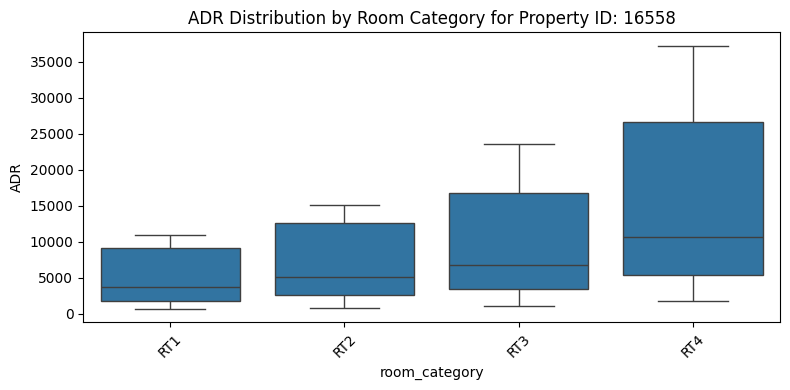

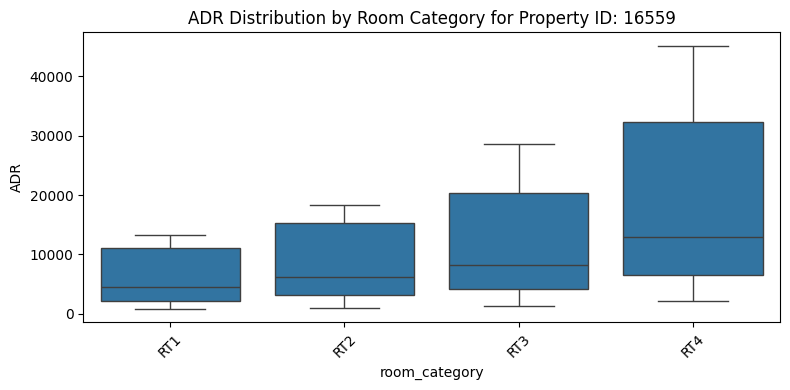

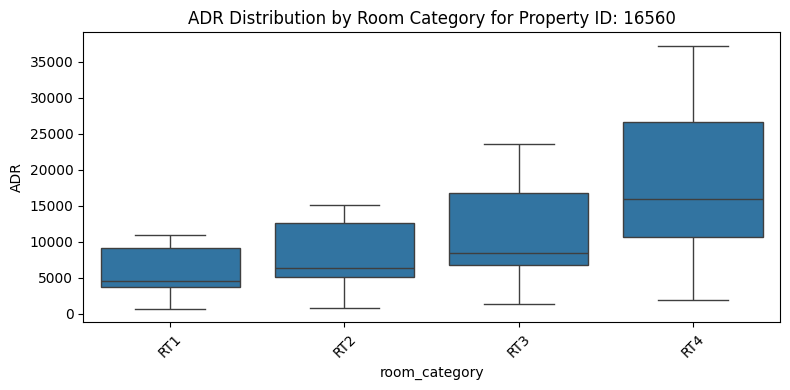

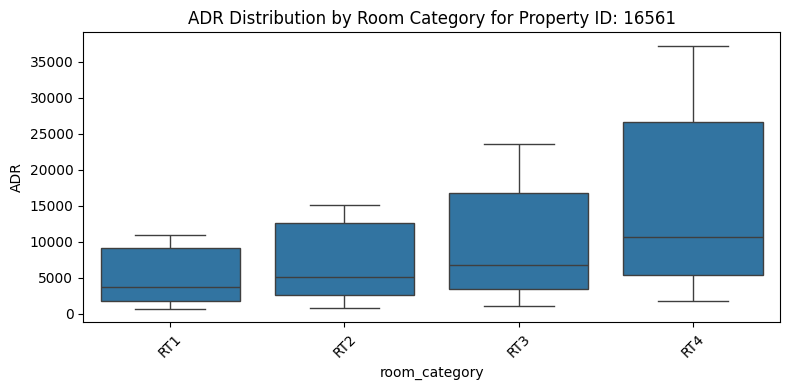

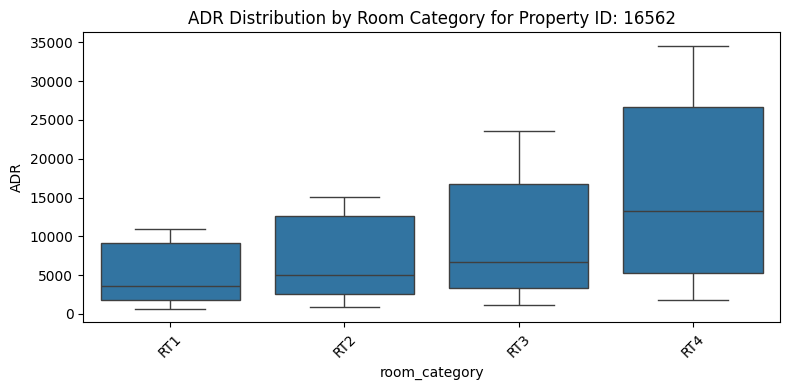

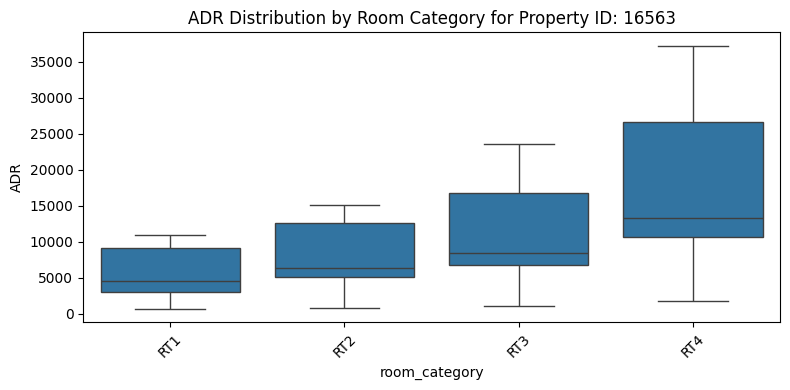

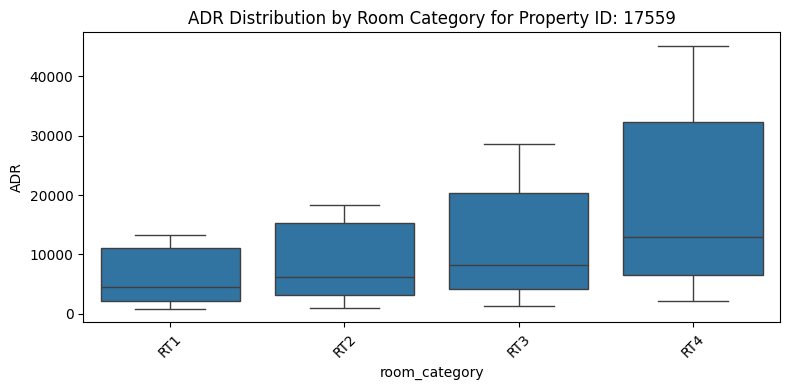

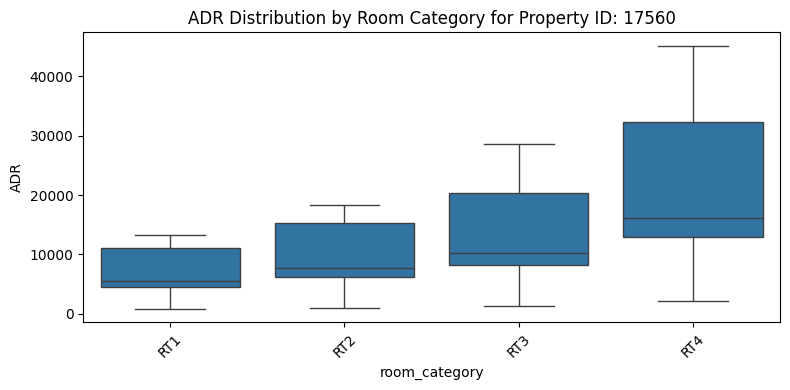

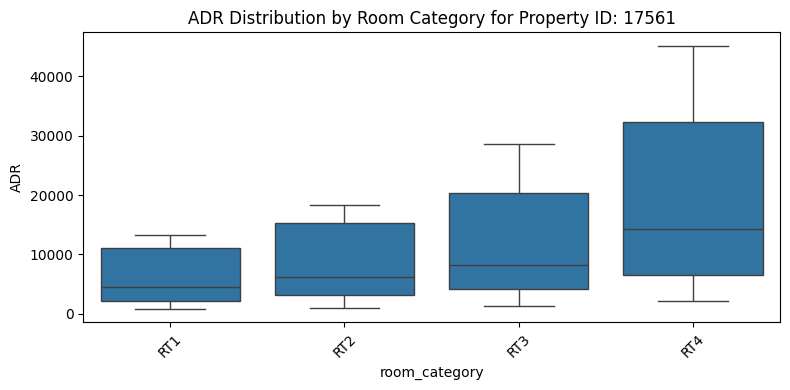

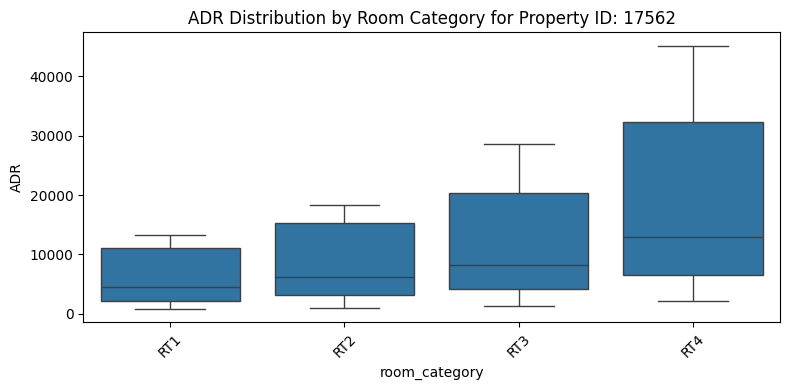

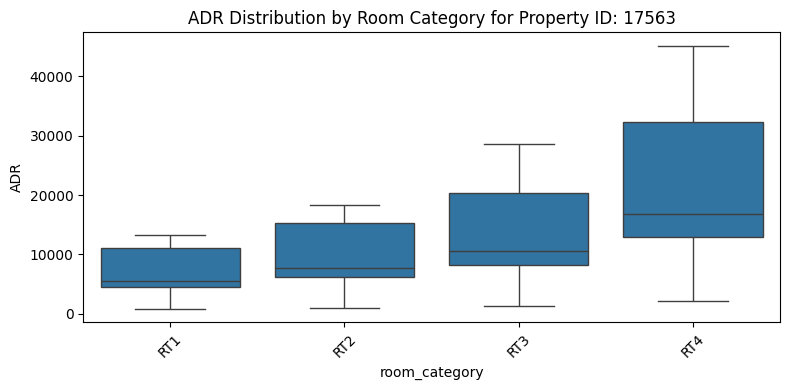

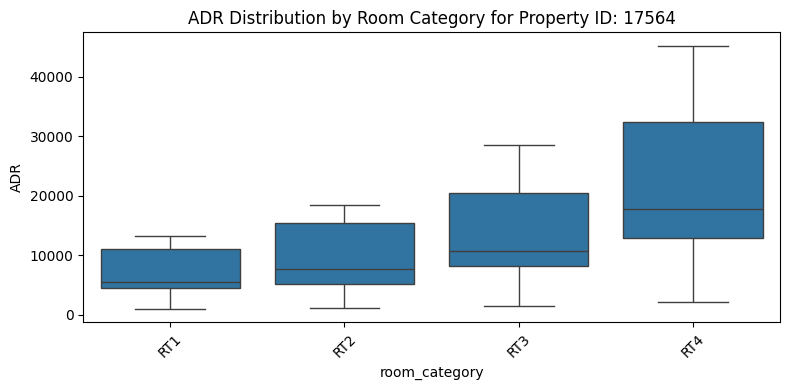

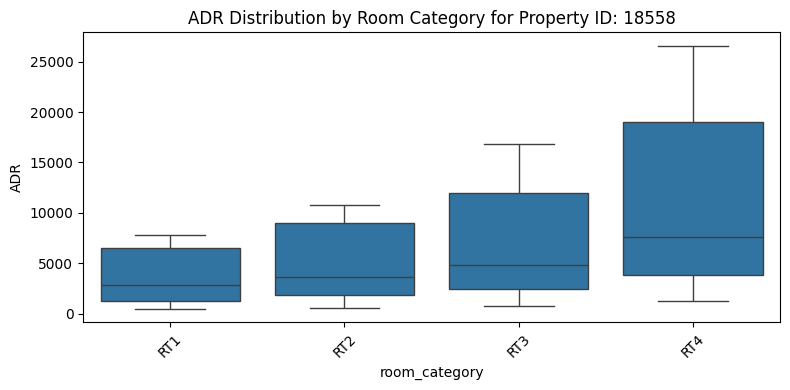

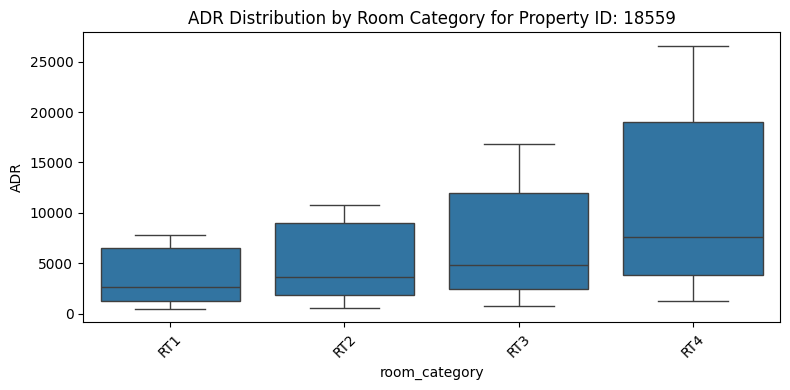

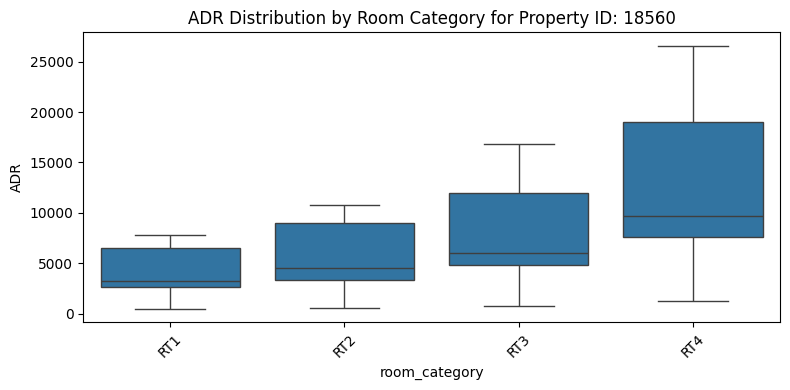

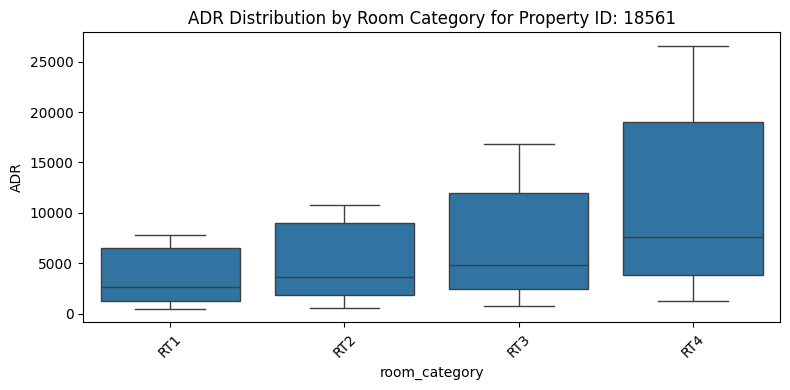

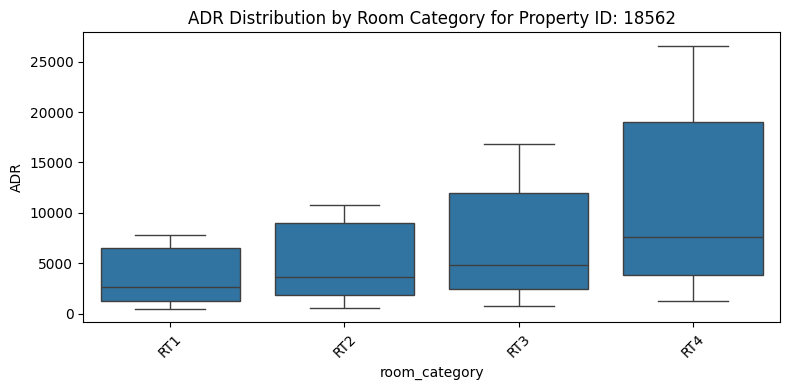

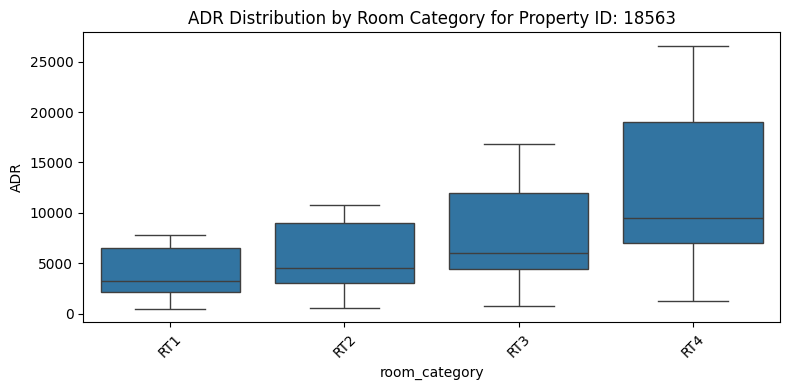

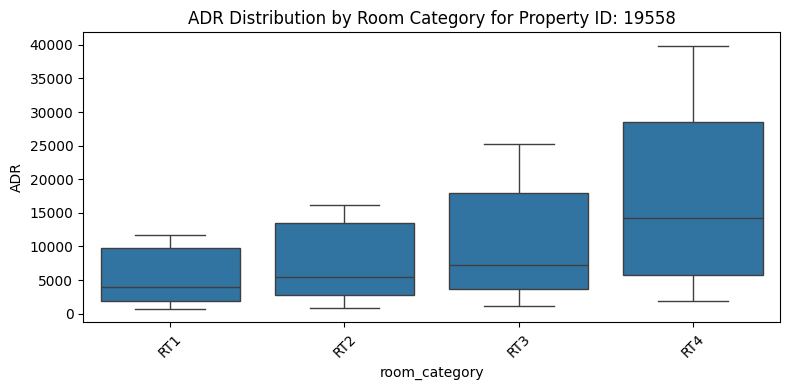

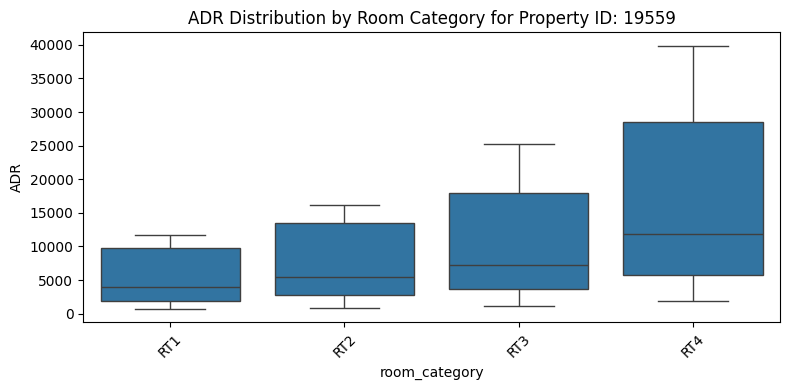

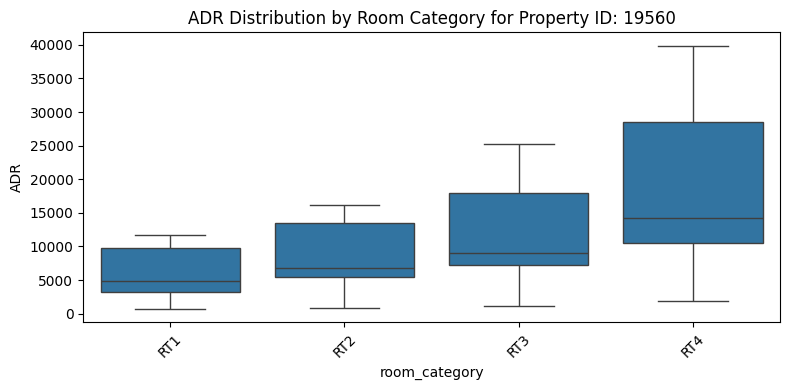

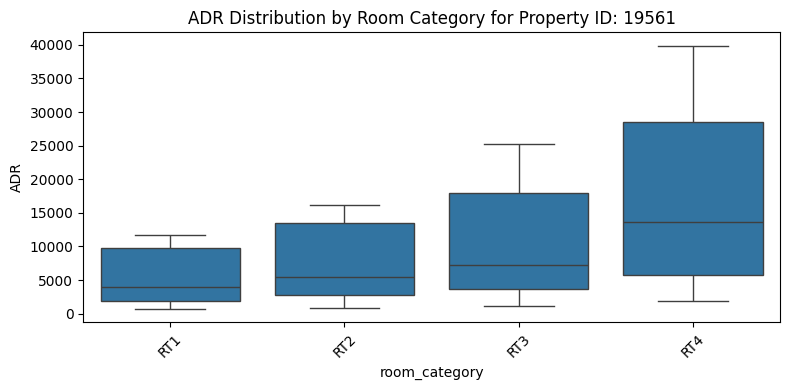

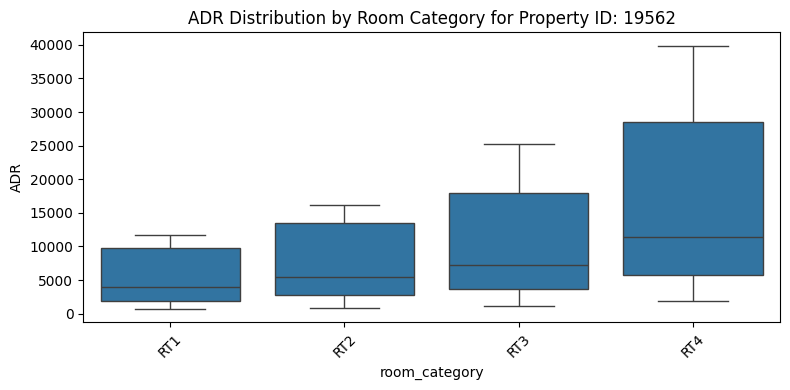

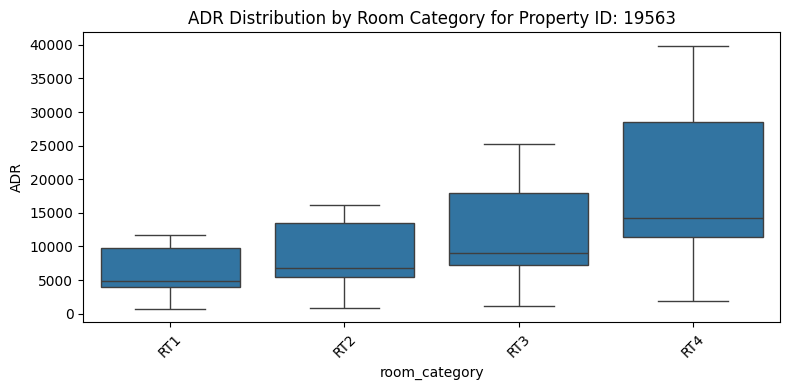

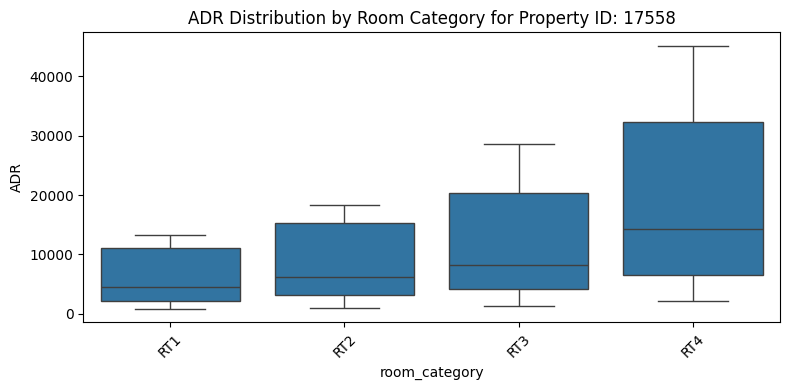

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

unique_properties = data['property_id'].unique()

for prop_id in unique_properties:
    plt.figure(figsize=(8, 4))
    
    subset = data[data['property_id'] == prop_id]
    
    # Calculate median ADR for each room_category
    ordered_categories = subset.groupby('room_category')['ADR'].median().sort_values().index

    # Plot with sorted x-axis
    sns.boxplot(data=subset, x='room_category', y='ADR', order=ordered_categories)
    
    plt.title(f"ADR Distribution by Room Category for Property ID: {prop_id}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Remove Outliers - To remove data entries with too low or too high ADRs (outliers) for each property_id and room_category combination

In [23]:
data

,property_id,room_category,booking_platform,ratings_given,ADR,category,city,occupancy_rate,day_type,lead_time_bucket,revenue,week_sin,week_cos
0,16558,RT2,direct offline,5.0,2520.000000,Luxury,Delhi,59.090909,Weekend,1-3_days,1489.090909,-0.120537,-0.992709
1,16559,RT1,direct offline,5.0,4420.000000,Luxury,Mumbai,66.666667,Weekend,8+_days,2946.666667,-0.120537,-0.992709
2,16559,RT1,direct offline,5.0,972.400000,Luxury,Mumbai,66.666667,Weekend,1-3_days,648.266667,-0.120537,-0.992709
3,16559,RT1,direct offline,4.0,1841.666667,Luxury,Mumbai,66.666667,Weekend,1-3_days,1227.777778,-0.120537,-0.992709
4,16559,RT1,direct offline,4.0,11050.000000,Luxury,Mumbai,96.666667,Weekend,1-3_days,10681.666667,-0.120537,-0.992709
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134585,19563,RT1,tripster,3.0,4875.000000,Business,Bangalore,43.333333,Weekday,1-3_days,2112.500000,0.354605,-0.935016
134586,19563,RT1,tripster,3.0,1300.000000,Business,Bangalore,43.333333,Weekday,same_day,563.333333,0.354605,-0.935016
134587,19563,RT2,tripster,3.0,16200.000000,Business,Bangalore,40.000000,Weekday,same_day,6480.000000,0.354605,-0.935016
134588,19563,RT3,tripster,3.0,18000.000000,Business,Bangalore,34.482759,Weekday,1-3_days,6206.896552,0.354605,-0.935016


In [24]:
def remove_adr_outliers(df):
    def iqr_filter(group):
        Q1 = group['ADR'].quantile(0.25)
        Q3 = group['ADR'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 0.4 * IQR
        upper_bound = Q3 + 0.3 * IQR
        return group[(group['ADR'] >= lower_bound) & (group['ADR'] <= upper_bound)]

    filtered_df = df.groupby(['property_id', 'room_category'], group_keys=False).apply(iqr_filter)
    return filtered_df.reset_index(drop=True)

# Usage:
cleaned_df = remove_adr_outliers(data)
data = cleaned_df
cleaned_df

C:\Users\Darshan\AppData\Local\Temp\ipykernel_25512\2778801641.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(['property_id', 'room_category'], group_keys=False).apply(iqr_filter)


,property_id,room_category,booking_platform,ratings_given,ADR,category,city,occupancy_rate,day_type,lead_time_bucket,revenue,week_sin,week_cos
0,16558,RT1,direct offline,5.0,3033.333333,Luxury,Delhi,94.736842,Weekday,4-7_days,2873.684210,-0.239316,-0.970942
1,16558,RT1,direct offline,3.0,5460.000000,Luxury,Delhi,73.684211,Weekday,4-7_days,4023.157895,-0.239316,-0.970942
2,16558,RT1,direct offline,5.0,1820.000000,Luxury,Delhi,63.157895,Weekday,4-7_days,1149.473684,-0.239316,-0.970942
3,16558,RT1,direct offline,5.0,1516.666667,Luxury,Delhi,63.157895,Weekday,1-3_days,957.894737,-0.239316,-0.970942
4,16558,RT1,direct offline,5.0,9100.000000,Luxury,Delhi,63.157895,Weekend,4-7_days,5747.368421,-0.239316,-0.970942
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128489,19563,RT4,tripster,4.0,28500.000000,Business,Bangalore,50.000000,Weekend,same_day,14250.000000,0.748511,-0.663123
128490,19563,RT4,tripster,3.0,14250.000000,Business,Bangalore,50.000000,Weekday,1-3_days,7125.000000,0.663123,-0.748511
128491,19563,RT4,tripster,4.0,28500.000000,Business,Bangalore,50.000000,Weekend,1-3_days,14250.000000,0.663123,-0.748511
128492,19563,RT4,tripster,3.0,11400.000000,Business,Bangalore,66.666667,Weekend,same_day,7600.000000,0.663123,-0.748511


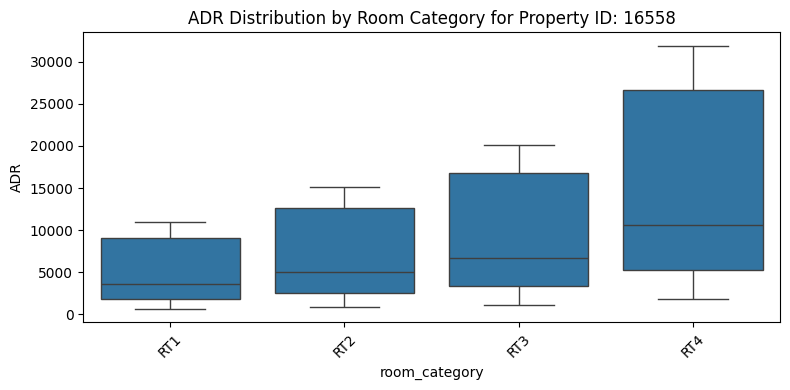

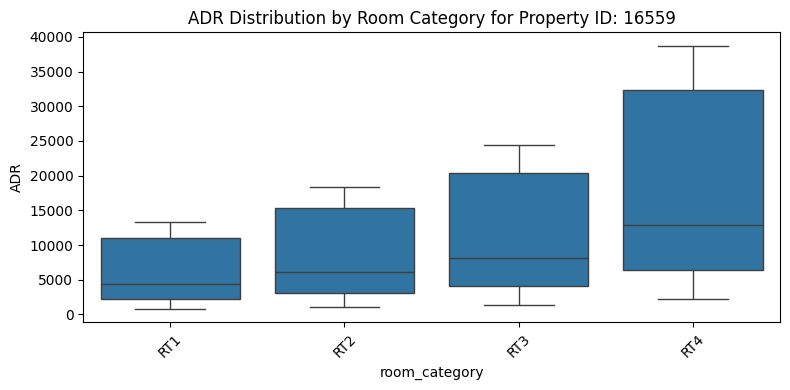

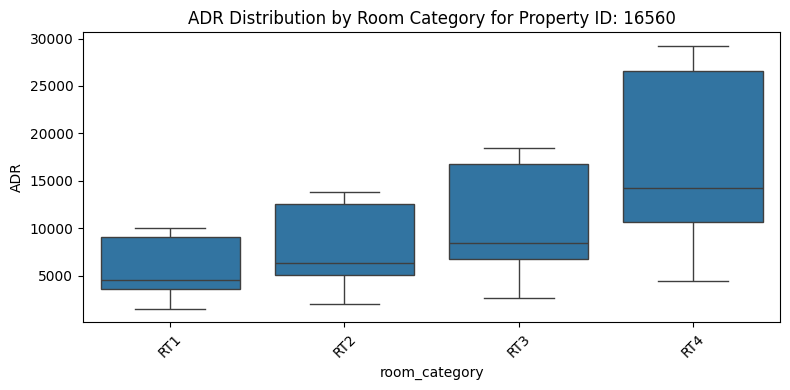

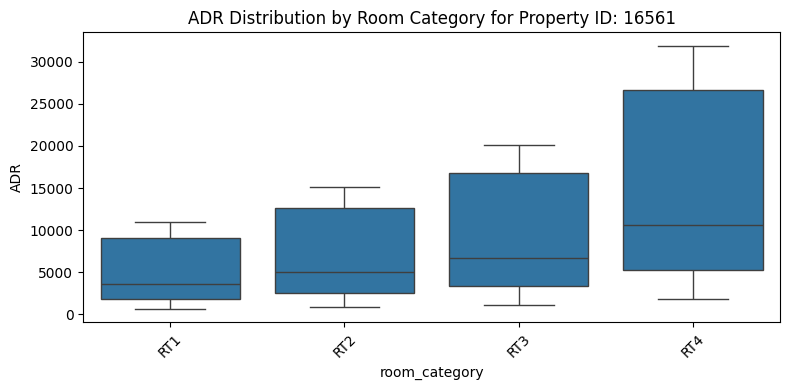

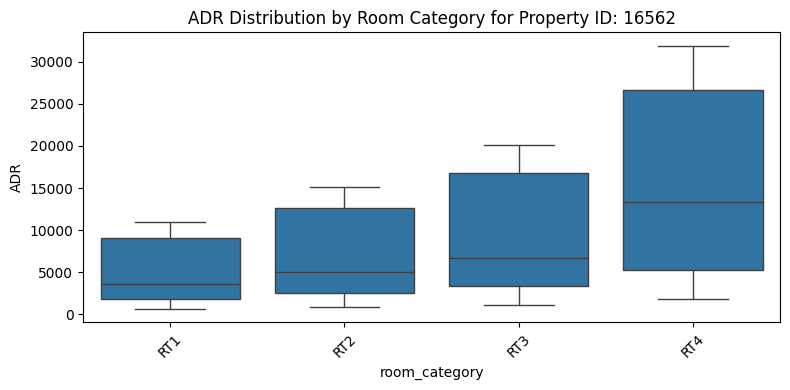

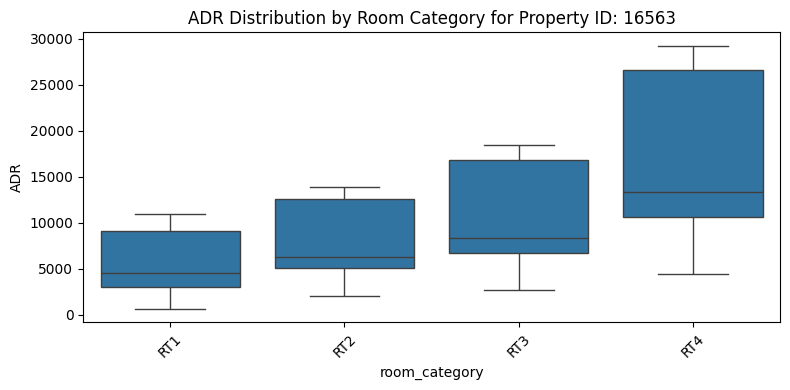

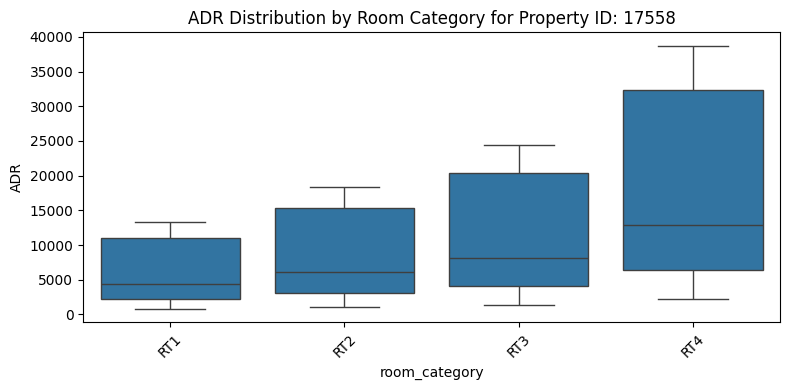

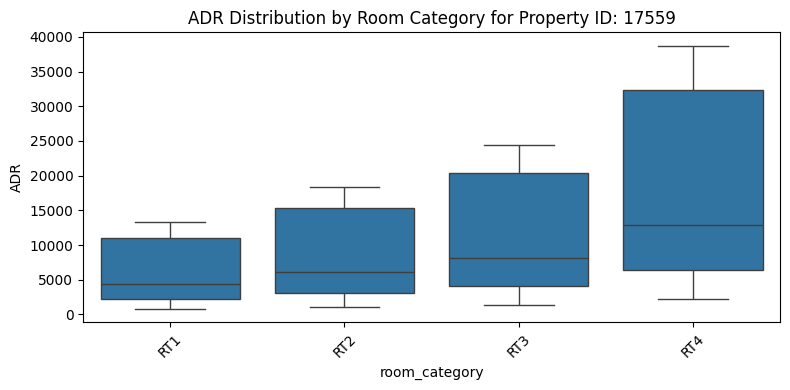

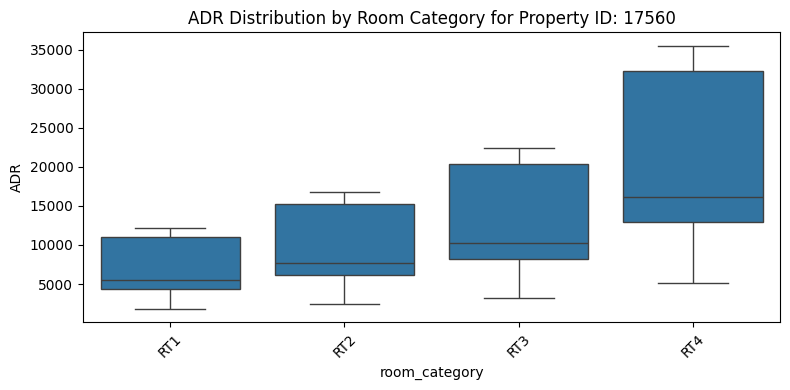

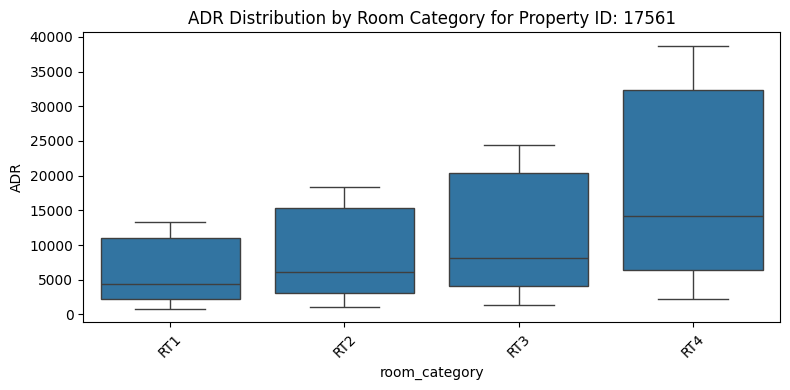

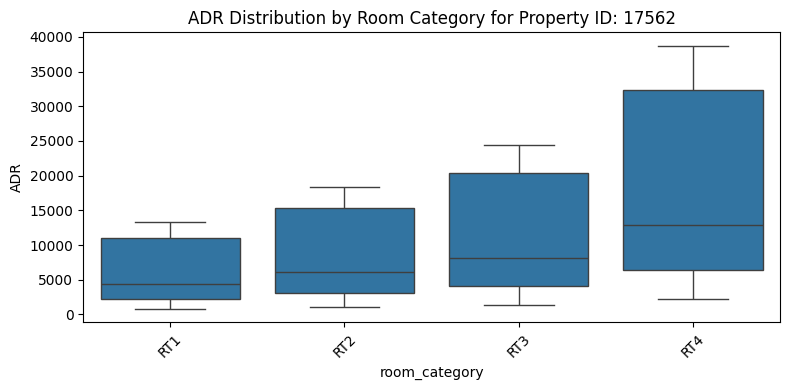

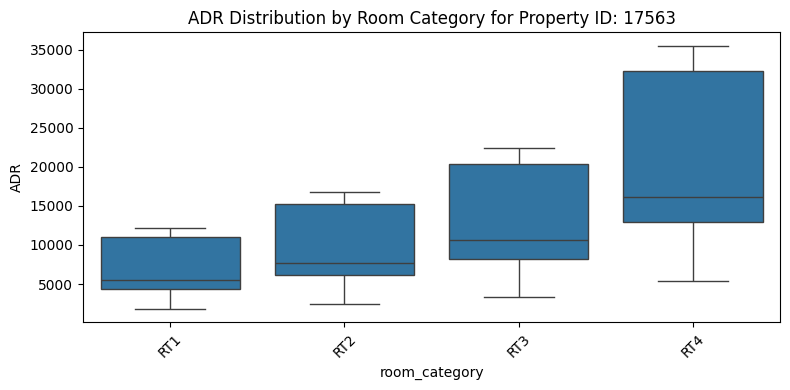

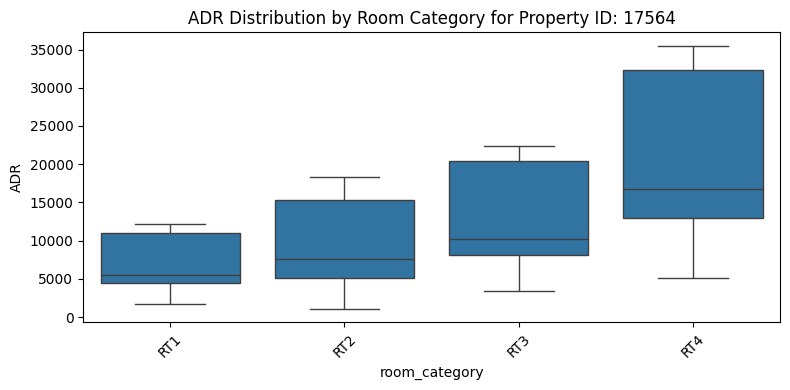

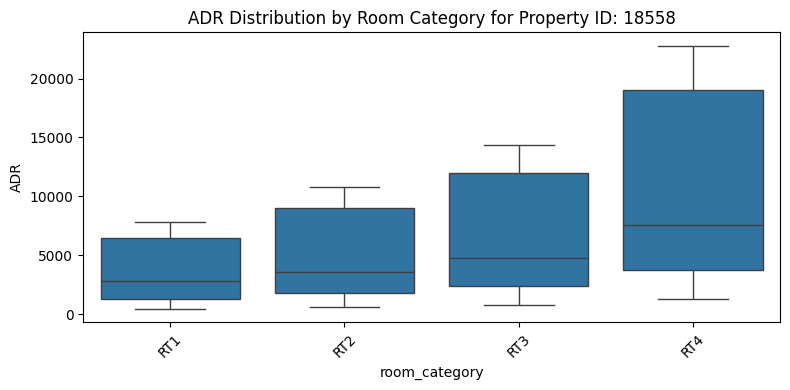

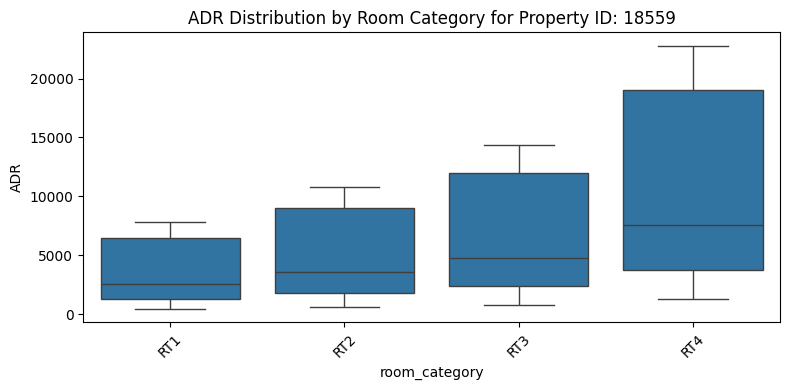

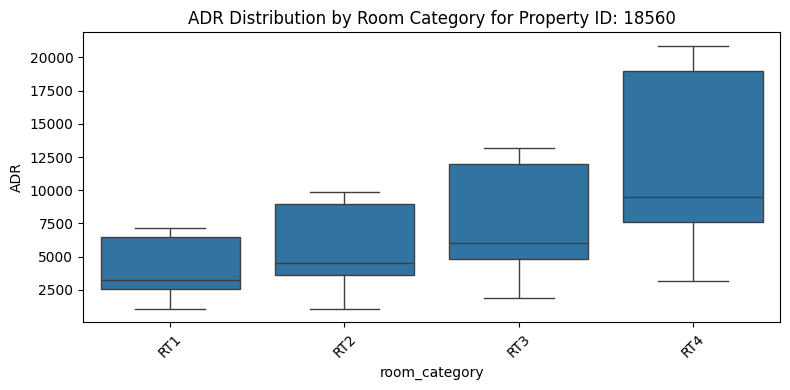

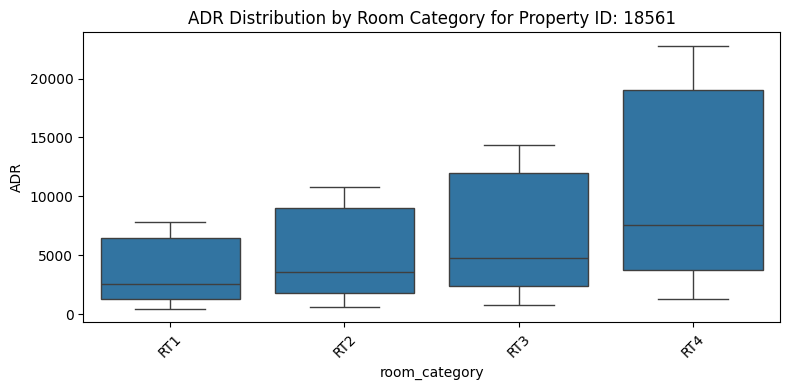

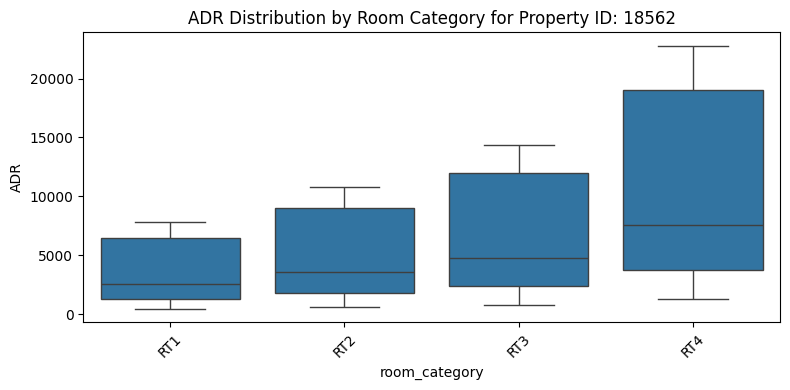

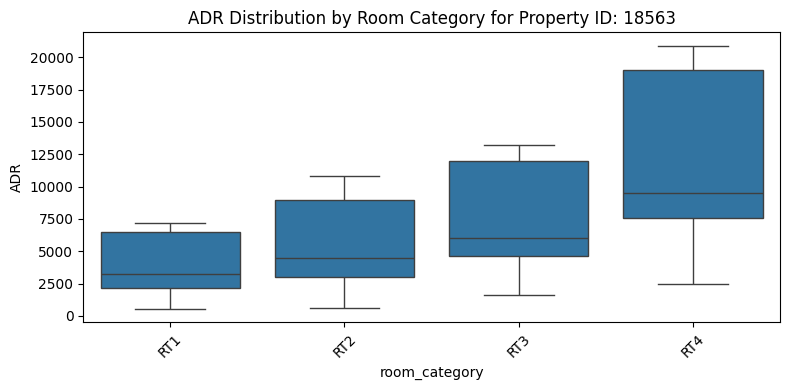

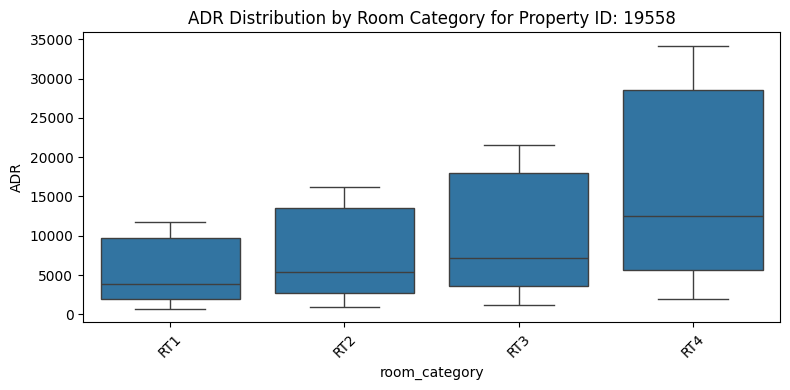

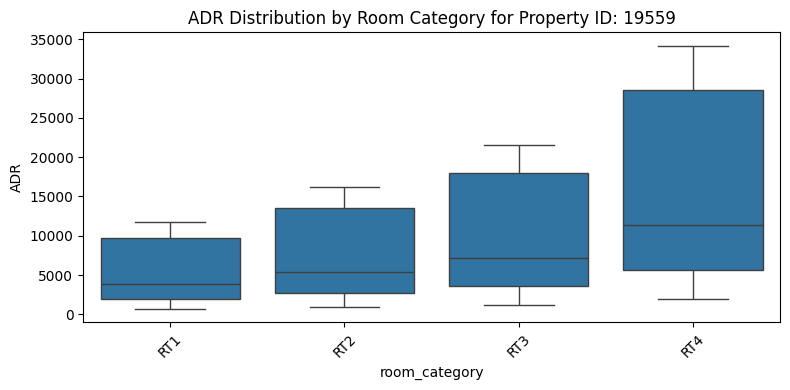

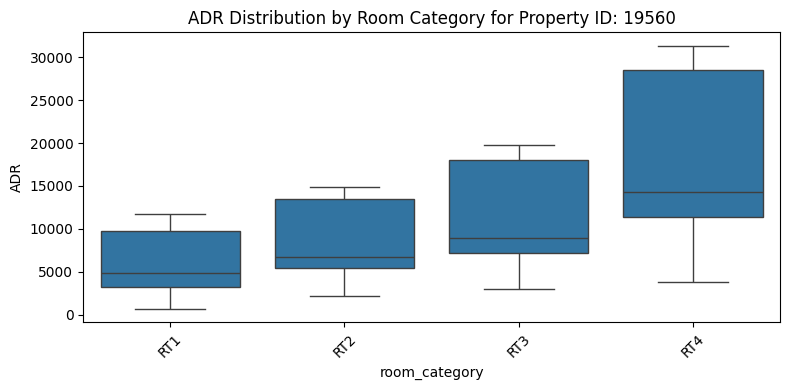

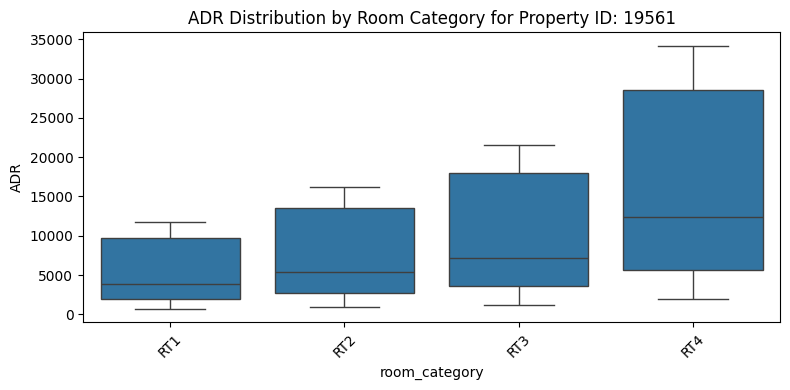

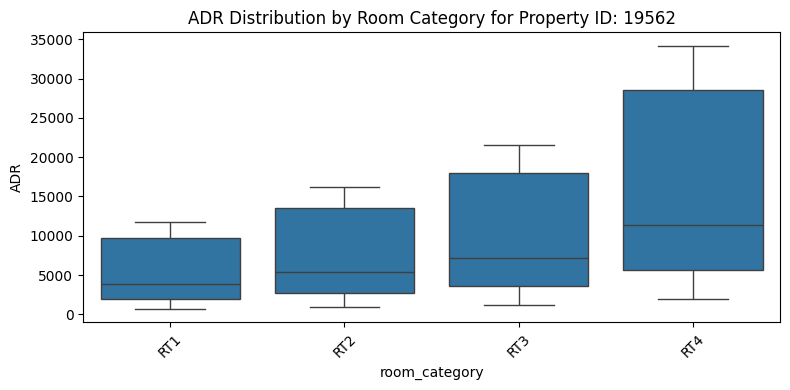

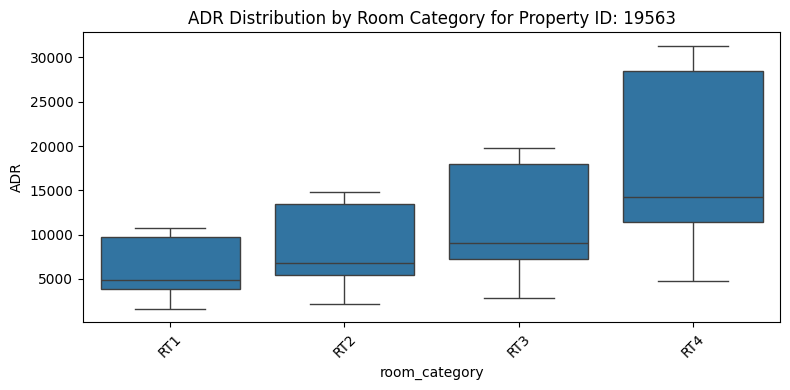

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

unique_properties = cleaned_df['property_id'].unique()

for prop_id in unique_properties:
    plt.figure(figsize=(8, 4))
    
    subset = cleaned_df[cleaned_df['property_id'] == prop_id]
    
    # Calculate median ADR for each room_category
    ordered_categories = subset.groupby('room_category')['ADR'].median().sort_values().index

    # Plot with sorted x-axis
    sns.boxplot(data=subset, x='room_category', y='ADR', order=ordered_categories)
    
    plt.title(f"ADR Distribution by Room Category for Property ID: {prop_id}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Z-Scores - Tells how far a value is from the mean, in terms of standard deviations.
### Usually, a Z-score > 3 is considered an outlier.
### Z-score of room_category within each property_id group
Z = (X-U)/sigma

In [26]:
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore

# Step 1: Convert 'room_category' to numeric
le = LabelEncoder()
data['room_category_encoded'] = le.fit_transform(data['room_category'])

# Step 2 & 3: Calculate Z-score within each property_id group
data['room_category_zscore'] = data.groupby('property_id')['room_category_encoded'].transform(zscore)

In [27]:
outlier_count = (abs(data['room_category_zscore']) > 2.5).sum()
print("Number of outliers:", outlier_count)
data.drop(["room_category_encoded","room_category_zscore"],axis=1, inplace=True)
# NO outliers

Number of outliers: 0


## Inconsistency in Dataset - Categorical Data

In [28]:
embed_cols = ['booking_platform','room_category','city','day_type']
for col in embed_cols:
    print(f"{col}: {data[col].unique()}")

# Hence No data inconsistency

booking_platform: ['direct offline' 'direct online' 'journey' 'logtrip' 'makeyourtrip'
 'others' 'tripster']
room_category: ['RT1' 'RT2' 'RT3' 'RT4']
city: ['Delhi' 'Mumbai' 'Hyderabad' 'Bangalore']
day_type: ['Weekday' 'Weekend']


## Data Correlation - Between Occupancy, ADR, Ratings, Lead Booking Time

### Occupancy v\s ADR

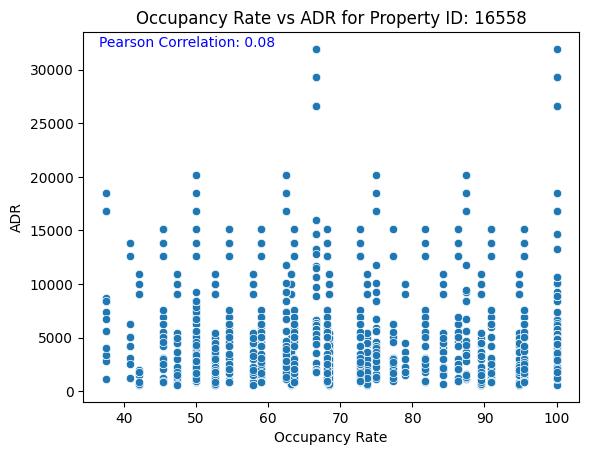

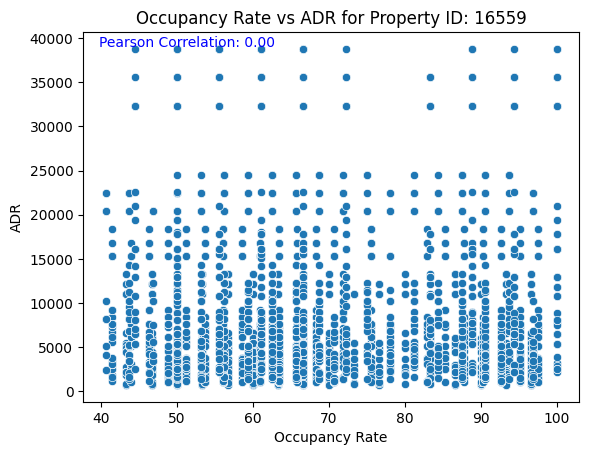

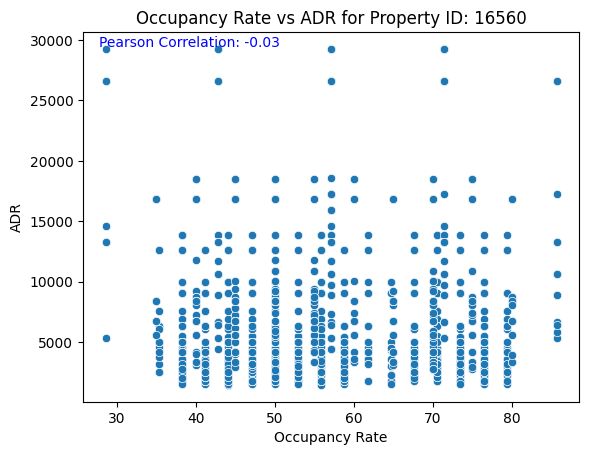

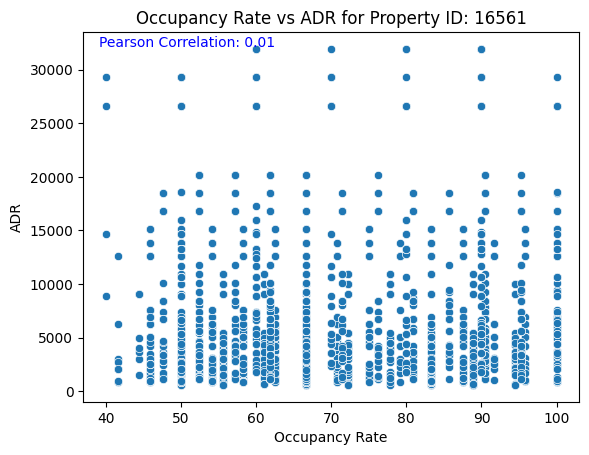

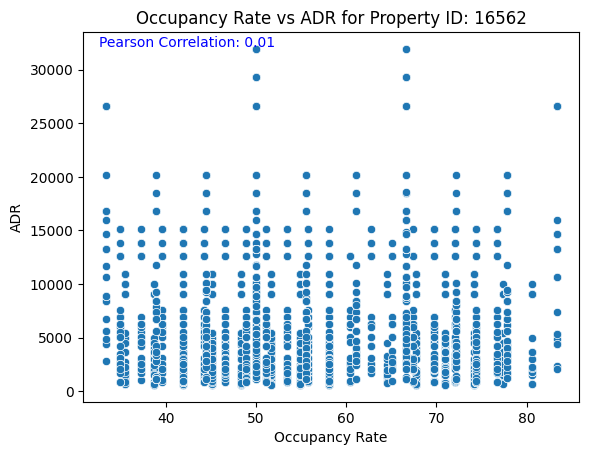

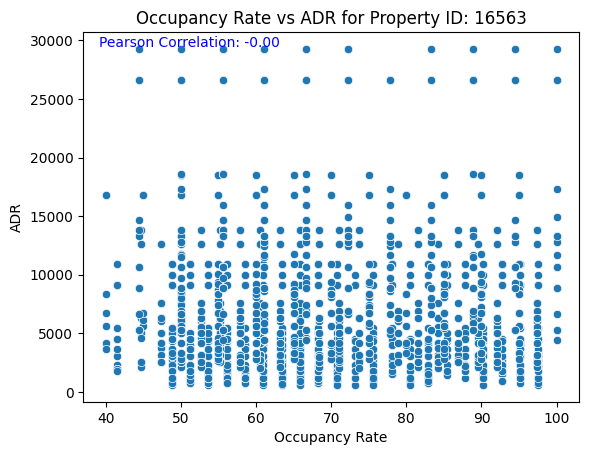

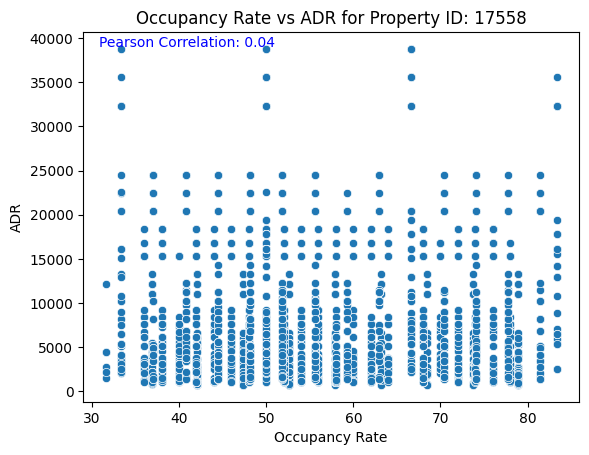

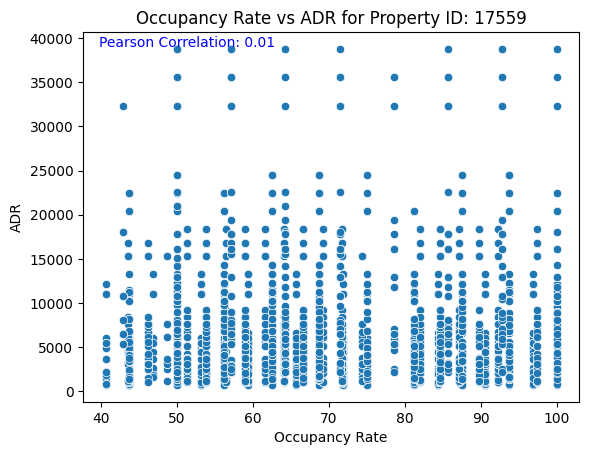

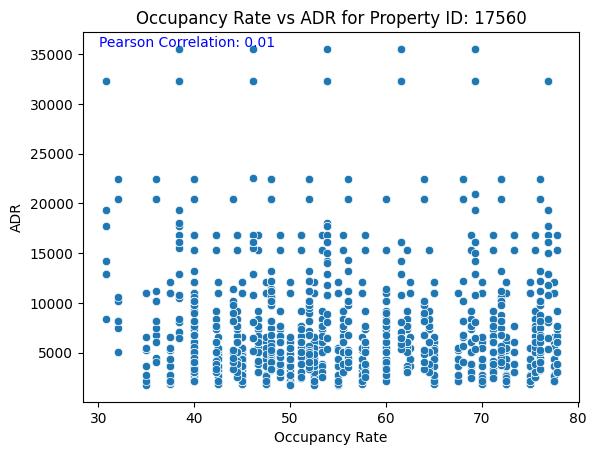

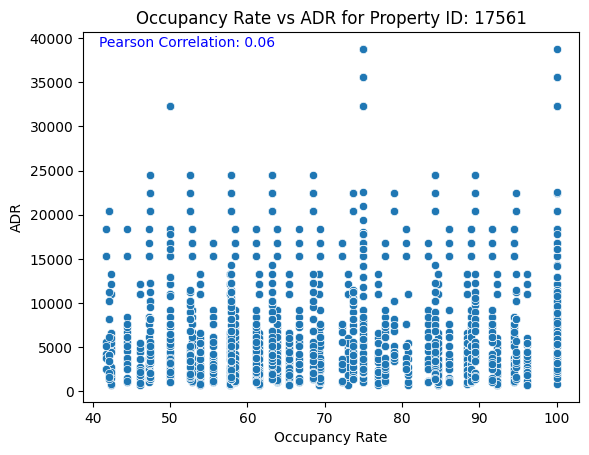

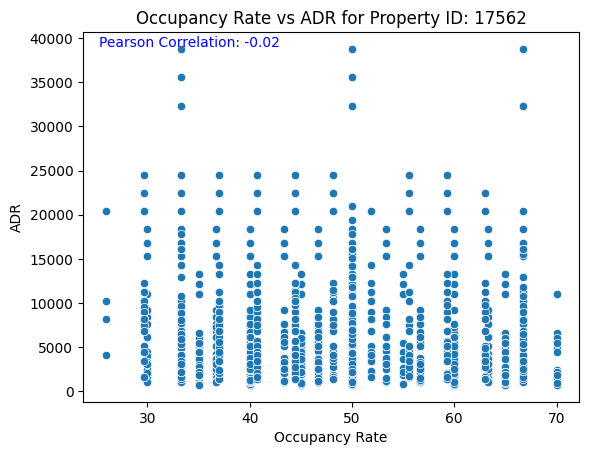

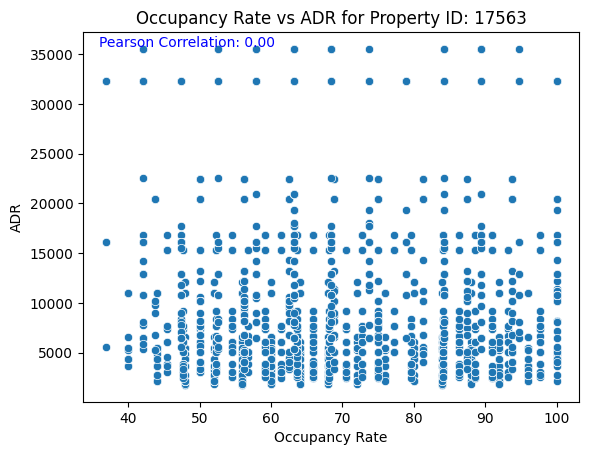

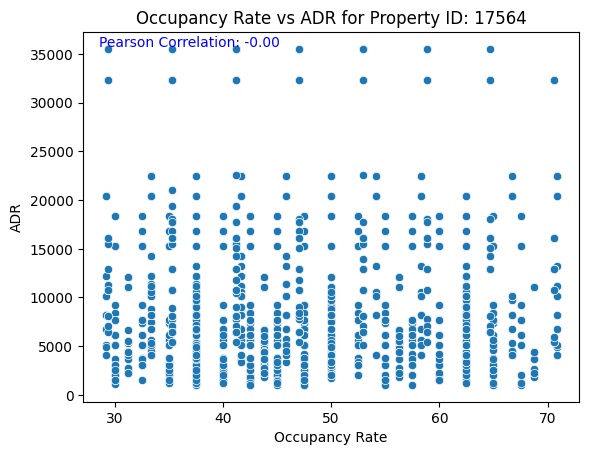

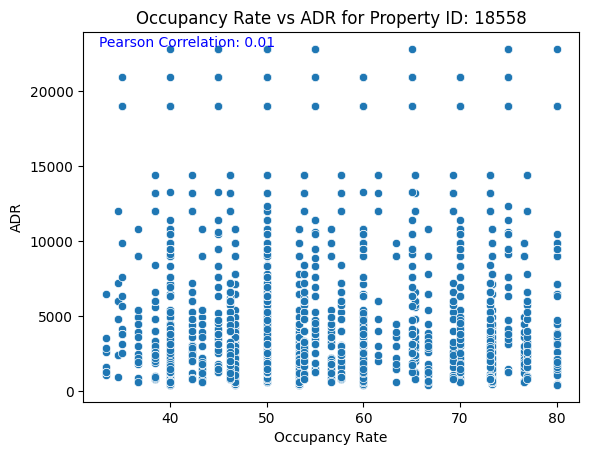

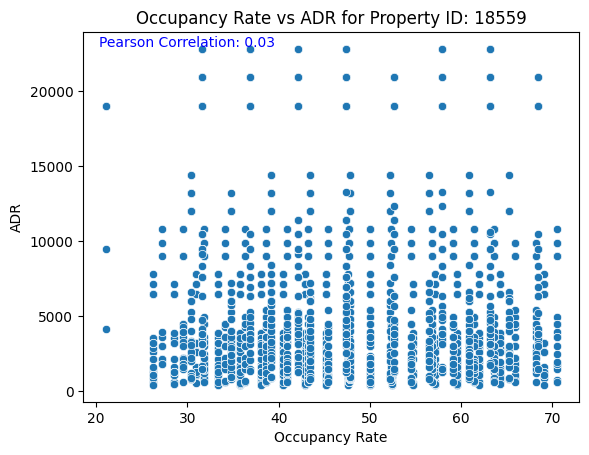

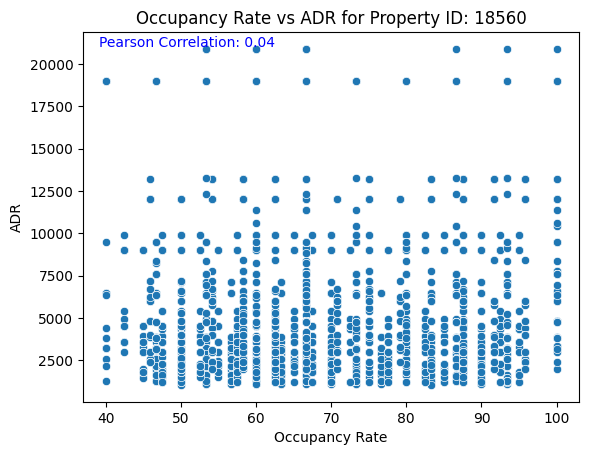

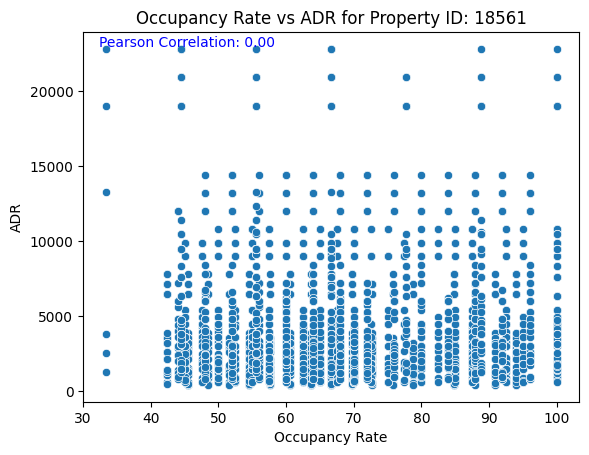

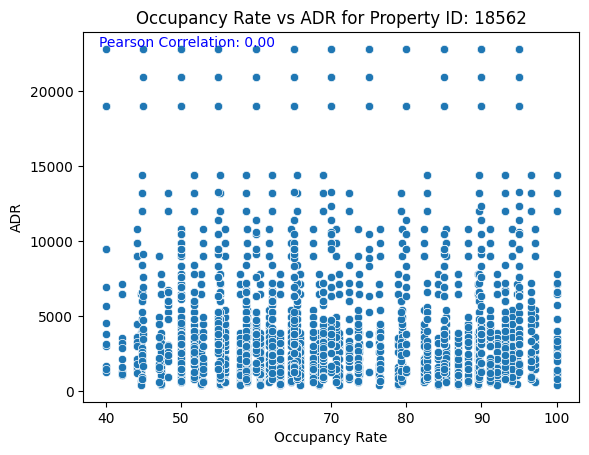

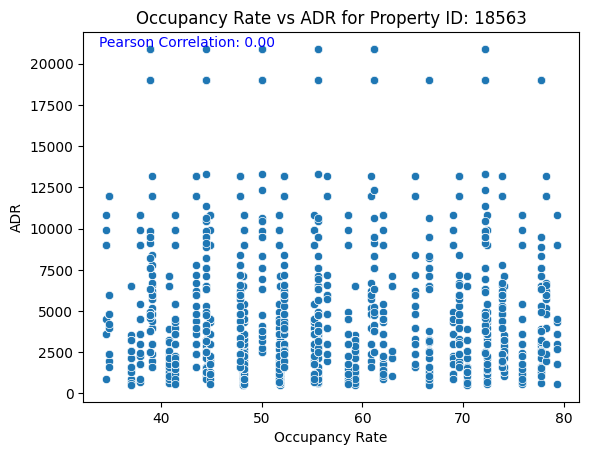

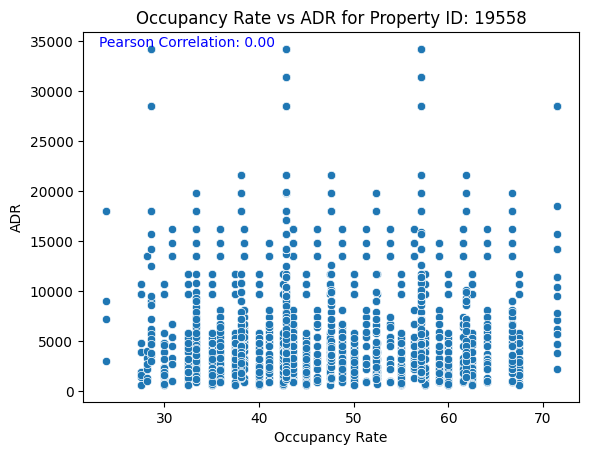

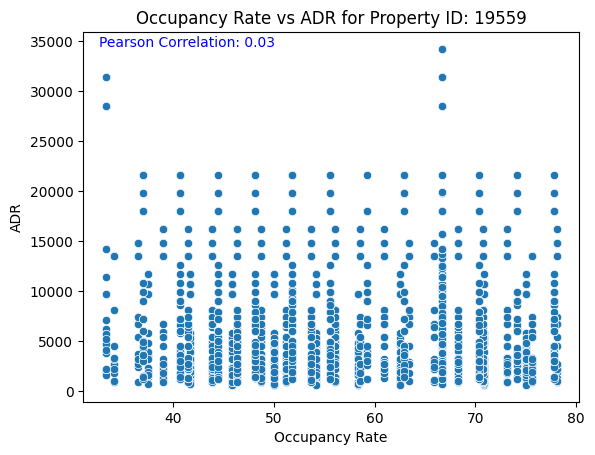

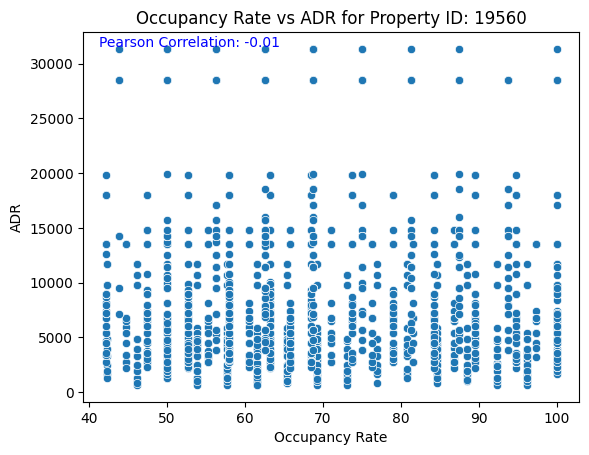

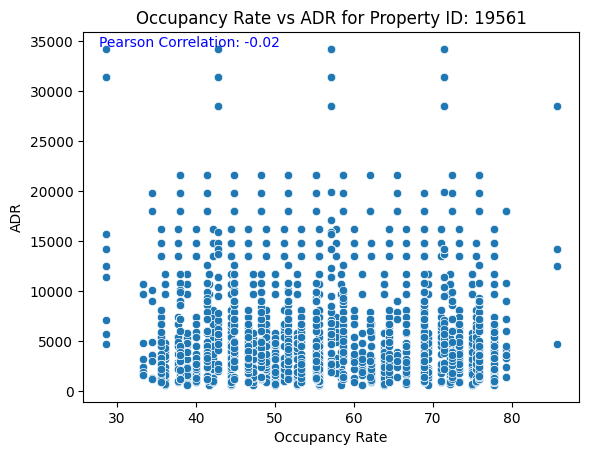

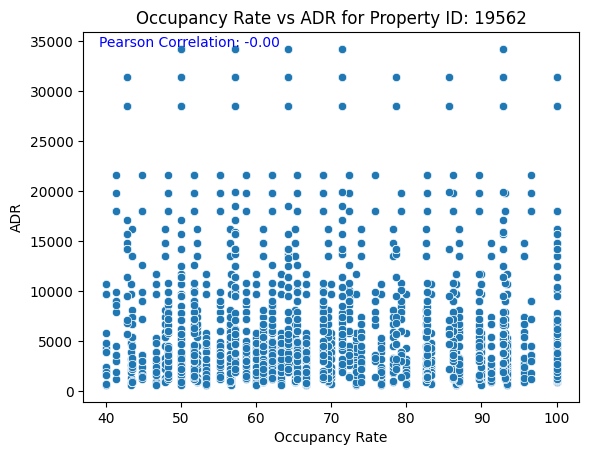

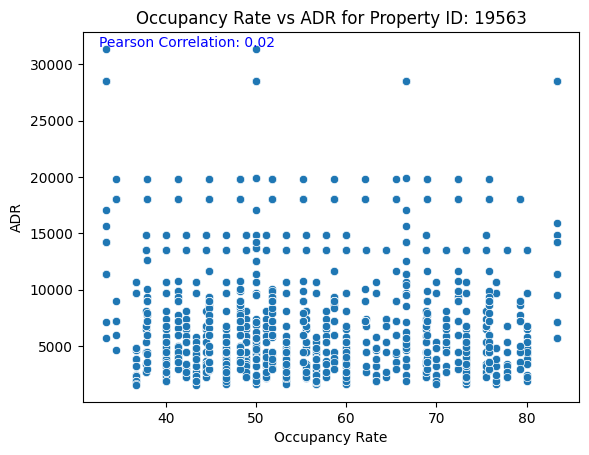

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get all unique property_ids
property_ids = data['property_id'].unique()

# Loop through each property and calculate + plot correlation
for prop_id in property_ids:
    prop_data = data[data['property_id'] == prop_id]
    
    if len(prop_data) < 2:
        continue  # skip if not enough data for correlation

    # Scatter plot
    sns.scatterplot(x='occupancy_rate', y='ADR', data=prop_data)
    plt.title(f'Occupancy Rate vs ADR for Property ID: {prop_id}')
    plt.xlabel('Occupancy Rate')
    plt.ylabel('ADR')
    
    # Calculate correlation
    correlation = prop_data['ADR'].corr(prop_data['occupancy_rate'], method='pearson')
    plt.figtext(0.15, 0.85, f'Pearson Correlation: {correlation:.2f}', fontsize=10, color='blue')

    plt.show()


## Filter out non-numeric columns

In [30]:
# Only keep numeric columns
X = data.select_dtypes(include=['number'])

## Check for Multicollinearity / Redundant Features
### Drop one of the features from any highly correlated pairs (correlation > 0.85 or < -0.85).

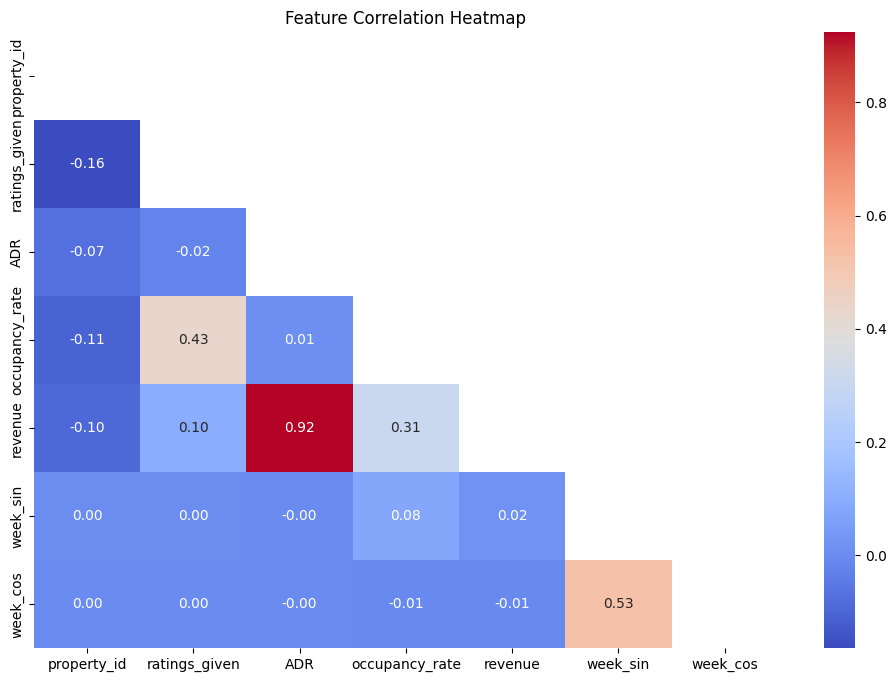

In [31]:
# Assuming 'X' is your feature DataFrame
plt.figure(figsize=(12, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=np.triu(corr_matrix))
plt.title("Feature Correlation Heatmap")
plt.show()

## PCA - removes redundancy and projects data onto fewer orthogonal axes

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Step 2: Apply PCA
pca = PCA(n_components=0.95)  # retain 95% variance
data_pca = pca.fit_transform(scaled_data)

print(f"Original features: {scaled_data.shape[1]}, After PCA: {data_pca.shape[1]}")


Original features: 7, After PCA: 6


In [33]:
data_pca

array([[ 0.23039523, -0.34879347,  2.81540195, -0.46352458, -0.8886149 ,
        -0.47231157],
       [-0.12087048, -0.91084176,  0.88098683, -1.09968262, -1.17182833,
        -0.46563715],
       [-0.77408914, -0.65020618,  1.87127433, -1.1278391 ,  0.30178548,
         0.04825059],
       ...,
       [ 3.00103654,  1.07112084, -2.71366669,  1.06557574,  1.26365374,
         0.32298447],
       [ 0.51867749,  1.62131094, -1.46071205,  1.25491669, -0.3094222 ,
        -0.2493748 ],
       [ 2.76542797, -0.78208219, -2.70012358,  1.05289622,  0.37269937,
         0.84424298]])

In [34]:
data.head()

,property_id,room_category,booking_platform,ratings_given,ADR,category,city,occupancy_rate,day_type,lead_time_bucket,revenue,week_sin,week_cos
0,16558,RT1,direct offline,5.0,3033.333333,Luxury,Delhi,94.736842,Weekday,4-7_days,2873.684210,-0.239316,-0.970942
1,16558,RT1,direct offline,3.0,5460.000000,Luxury,Delhi,73.684211,Weekday,4-7_days,4023.157895,-0.239316,-0.970942
2,16558,RT1,direct offline,5.0,1820.000000,Luxury,Delhi,63.157895,Weekday,4-7_days,1149.473684,-0.239316,-0.970942
3,16558,RT1,direct offline,5.0,1516.666667,Luxury,Delhi,63.157895,Weekday,1-3_days,957.894737,-0.239316,-0.970942
4,16558,RT1,direct offline,5.0,9100.000000,Luxury,Delhi,63.157895,Weekend,4-7_days,5747.368421,-0.239316,-0.970942


In [35]:
data.drop('ADR',axis=1, inplace=True)
data.to_csv("data.csv")

## Import data.csv

In [8]:
data = pd.read_csv("data.csv")

In [9]:
data.drop("Unnamed: 0", axis = 1, inplace=True)

## Data preporcessing & Model building

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Flatten, Input, Concatenate, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assume data1 is already defined
df = data.copy()

# Label Encoding
label_enc = LabelEncoder()
df['room_category'] = label_enc.fit_transform(df['room_category'])

lead_time_mapping = {
    "8+_days": 0,
    "4-7_days": 1,
    "1-3_days": 2,
    "same_day": 3
}

df['lead_time_bucket'] = df['lead_time_bucket'].map(lead_time_mapping)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['category', 'day_type'], drop_first=True)

# Standard Scaling
scaler = StandardScaler()
df[['revenue']] = scaler.fit_transform(df[['revenue']])

# Embedding prep: Convert to categorical integer codes
for col in ['property_id', 'booking_platform', 'city']:
    df[col] = df[col].astype('category').cat.codes

# Features and target
X = df.drop(columns=['occupancy_rate'])
y = df['occupancy_rate'].values.reshape(-1, 1)

# Scale target
target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y)


In [11]:
X

,property_id,room_category,booking_platform,ratings_given,city,lead_time_bucket,revenue,week_sin,week_cos,category_Luxury,day_type_Weekend
0,0,0,0,5.0,1,1,-0.490714,-0.239316,-0.970942,True,False
1,0,0,0,3.0,1,1,-0.227346,-0.239316,-0.970942,True,False
2,0,0,0,5.0,1,1,-0.885765,-0.239316,-0.970942,True,False
3,0,0,0,5.0,1,2,-0.929660,-0.239316,-0.970942,True,False
4,0,0,0,5.0,1,1,0.167705,-0.239316,-0.970942,True,True
...,...,...,...,...,...,...,...,...,...,...,...
128489,24,3,6,4.0,0,3,2.115830,0.748511,-0.663123,False,True
128490,24,3,6,3.0,0,2,0.483348,0.663123,-0.748511,False,False
128491,24,3,6,4.0,0,2,2.115830,0.663123,-0.748511,False,True
128492,24,3,6,3.0,0,3,0.592180,0.663123,-0.748511,False,True


In [22]:
from keras.models import Model
from keras.layers import Input, Dense, Embedding, Concatenate, Dropout, BatchNormalization, LeakyReLU, Lambda
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.optimizers import Adam
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# === Step 1: Inputs and embeddings ===
embedding_layers = []
inputs = {}

cat_embed_cols = ['property_id', 'booking_platform', 'city', 'room_category', 'lead_time_bucket', 'ratings_given']

# Embedding categorical features
for col in cat_embed_cols:
    num_unique = X_train[col].nunique()
    input_cat = Input(shape=(1,), name=col)
    embed_dim = min(50, num_unique // 2)
    embedding = Embedding(input_dim=num_unique + 1, output_dim=embed_dim)(input_cat)
    embedding = Lambda(lambda x: tf.squeeze(x, axis=1), output_shape=lambda s: (s[0], s[2]))(embedding)
    embedding_layers.append(embedding)
    inputs[col] = input_cat

numerical_inputs = ['revenue', 'week_sin', 'week_cos', 'category_Luxury', 'day_type_Weekend']

# Normalize numerical features
scaler = StandardScaler()
X_train[numerical_inputs] = scaler.fit_transform(X_train[numerical_inputs])
X_test[numerical_inputs] = scaler.transform(X_test[numerical_inputs])

for col in numerical_inputs:
    inputs[col] = Input(shape=(1,), name=col)

# === Step 2: Merge inputs ===
x = Concatenate()(embedding_layers + [inputs[col] for col in numerical_inputs])

# === Step 3: Neural Network Architecture ===
x = Dense(256)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.3)(x)

x = Dense(128)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Dropout(0.3)(x)

x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

output = Dense(1)(x)

model = Model(inputs=list(inputs.values()), outputs=output)

import tensorflow as tf

def r2_score(y_true, y_pred):
    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - SS_res / (SS_tot + tf.keras.backend.epsilon())


# === Step 5: Compile model ===
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mae',
    metrics=[r2_score]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ property_id (InputLayer)      │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ booking_platform (InputLayer) │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ city (InputLayer)             │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ room_category (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lead_time_bucket (InputLayer) │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ratings_given (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_21 (Embedding)      │ (None, 1, 12)             │             312 │ property_id[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_22 (Embedding)      │ (None, 1, 3)              │              24 │ booking_platform[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_23 (Embedding)      │ (None, 1, 2)              │              10 │ city[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_24 (Embedding)      │ (None, 1, 2)              │              10 │ room_category[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_25 (Embedding)      │ (None, 1, 2)              │              10 │ lead_time_bucket[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_26 (Embedding)      │ (None, 1, 2)              │              12 │ ratings_given[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_21 (Lambda)            │ (None, 12)                │               0 │ embedding_21[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_22 (Lambda)            │ (None, 3)                 │               0 │ embedding_22[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_23 (Lambda)            │ (None, 2)                 │               0 │ embedding_23[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_24 (Lambda)            │ (None, 2)                 │               0 │ embedding_24[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_25 (Lambda)            │ (None, 2)                 │               0 │ embedding_25[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 50,811 (198.48 KB)

 Trainable params: 49,915 (194.98 KB)

 Non-trainable params: 896 (3.50 KB)

In [23]:
# === Step 6: Prepare input dictionary ===
def prepare_input_dict(X_df):
    return {col: X_df[col].values for col in cat_embed_cols + numerical_inputs}

X_train_dict = prepare_input_dict(X_train)
X_test_dict = prepare_input_dict(X_test)

# === Step 7: Callbacks ===
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# === Step 8: Model training ===
history = model.fit(
    X_train_dict, y_train,
    validation_data=(X_test_dict, y_test),
    epochs=100,
    batch_size=64,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.6909 - r2_score: 0.1966 - val_loss: 0.5695 - val_r2_score: 0.4313 - learning_rate: 0.0010
Epoch 2/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5885 - r2_score: 0.3893 - val_loss: 0.5334 - val_r2_score: 0.4544 - learning_rate: 0.0010
Epoch 3/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.5663 - r2_score: 0.4240 - val_loss: 0.5140 - val_r2_score: 0.4885 - learning_rate: 0.0010
Epoch 4/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5544 - r2_score: 0.4385 - val_loss: 0.4990 - val_r2_score: 0.5011 - learning_rate: 0.0010
Epoch 5/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5438 - r2_score: 0.4510 - val_loss: 0.4884 - val_r2_score: 0.5225 - learning_rate: 0.0010
Epoch 6/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5423 - r2_score: 0.4552 - val_loss: 0.4880 - val_r2_score: 0.5134 - learning_rate: 0.0010
Epoch 7/100
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5390

In [24]:
# 8. Evaluate the model
y_pred = model.predict(X_test_dict)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Evaluation Metrics:")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# 9. Save model and optionally scalers or encoders
model_path = "final_model.h5"
model.save(model_path)
print(f"\n✅ Model saved to {model_path}")

# Optional: Save preprocessing objects like scaler
# joblib.dump(y_scaler, "y_scaler.save")

804/804 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step



📊 Evaluation Metrics:
MAE  = 0.4388
MSE  = 0.4172
RMSE = 0.6459
R²   = 0.5832

✅ Model saved to final_model.h5


In [25]:
import numpy as np
import pandas as pd

# Example data (replace with your actual test data)
original_occupancy = np.array([0.75, 0.60, 0.85, 0.40])  # actual
predicted_occupancy = np.array([0.70, 0.65, 0.80, 0.35])  # predicted
original_ADR = np.array([120, 100, 150, 80])  # actual ADR

# Linear proportional scaling of ADR with occupancy
def adjust_ADR(original_adr, original_occ, predicted_occ):
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        adjusted_adr = original_adr * (predicted_occ / original_occ)
        # Optional: clip ADR to not exceed original ADR too wildly (e.g., within ±20%)
        adjusted_adr = np.clip(adjusted_adr, 0.8 * original_adr, 1.2 * original_adr)
    return adjusted_adr

predicted_ADR = adjust_ADR(original_ADR, original_occupancy, predicted_occupancy)

# Create DataFrame for clarity
df_result = pd.DataFrame({
    'Original Occupancy': original_occupancy,
    'Predicted Occupancy': predicted_occupancy,
    'Original ADR': original_ADR,
    'Predicted ADR': predicted_ADR
})

print(df_result)


   Original Occupancy  Predicted Occupancy  Original ADR  Predicted ADR
0                0.75                 0.70           120     112.000000
1                0.60                 0.65           100     108.333333
2                0.85                 0.80           150     141.176471
3                0.40                 0.35            80      70.000000
